In [1]:
"""
pca_analysis.py

Purpose:
- Perform Principal Component Analysis (PCA) on cleaned, transposed cryptocurrency price data.
- Reduce dimensionality to top principal components capturing most variance.
- Save PCA results for clustering.
- Provide insights via explained variance and cumulative variance plots.

Author: [Your Name]
Date: 2025-08-14
"""

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# 1. Load transposed, cleaned dataset
df_transposed = pd.read_csv('../data/processed/crypto_dataset_transposed.csv')
print(f"Loaded transposed dataset: {df_transposed.shape}")

Loaded transposed dataset: (30, 366)


In [3]:
# 2. Separate symbols and numeric data
symbols = df_transposed['Symbol']
data = df_transposed.drop('Symbol', axis=1)

# 3. Standardize the data (mean=0, var=1)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
print(f"Data standardized: mean={data_scaled.mean():.4f}, std={data_scaled.std():.4f}")

Data standardized: mean=-0.0000, std=1.0000


In [4]:
# 4. Perform PCA keeping all components to analyze variance
pca = PCA(n_components=None)
pca_scores = pca.fit_transform(data_scaled)

# 5. Explained variance ratio and cumulative variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("\nExplained variance ratio per principal component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), start=1):
    print(f"PC{i}: {var:.4%} (Cumulative: {cum_var:.4%})")


Explained variance ratio per principal component:
PC1: 99.9666% (Cumulative: 99.9666%)
PC2: 0.0333% (Cumulative: 99.9999%)
PC3: 0.0000% (Cumulative: 100.0000%)
PC4: 0.0000% (Cumulative: 100.0000%)
PC5: 0.0000% (Cumulative: 100.0000%)
PC6: 0.0000% (Cumulative: 100.0000%)
PC7: 0.0000% (Cumulative: 100.0000%)
PC8: 0.0000% (Cumulative: 100.0000%)
PC9: 0.0000% (Cumulative: 100.0000%)
PC10: 0.0000% (Cumulative: 100.0000%)
PC11: 0.0000% (Cumulative: 100.0000%)
PC12: 0.0000% (Cumulative: 100.0000%)
PC13: 0.0000% (Cumulative: 100.0000%)
PC14: 0.0000% (Cumulative: 100.0000%)
PC15: 0.0000% (Cumulative: 100.0000%)
PC16: 0.0000% (Cumulative: 100.0000%)
PC17: 0.0000% (Cumulative: 100.0000%)
PC18: 0.0000% (Cumulative: 100.0000%)
PC19: 0.0000% (Cumulative: 100.0000%)
PC20: 0.0000% (Cumulative: 100.0000%)
PC21: 0.0000% (Cumulative: 100.0000%)
PC22: 0.0000% (Cumulative: 100.0000%)
PC23: 0.0000% (Cumulative: 100.0000%)
PC24: 0.0000% (Cumulative: 100.0000%)
PC25: 0.0000% (Cumulative: 100.0000%)
PC26: 0.0

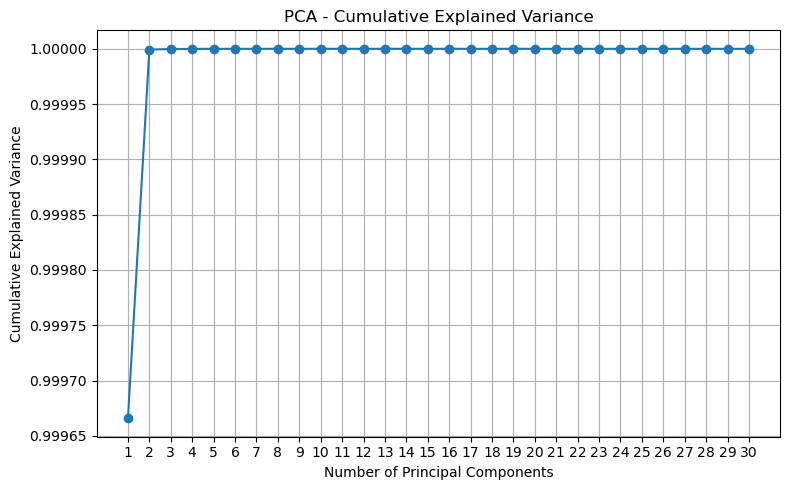

In [5]:
# 6. Choose number of PCs to keep (e.g., top 2 for visualization/clustering)
n_components = 2
pca_scores_reduced = pca_scores[:, :n_components]

# 8. Optional: Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.xticks(range(1, len(explained_variance) + 1))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
# 7. Save the PCA results with Symbols
pca_df = pd.DataFrame(pca_scores_reduced, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df.insert(0, 'Symbol', symbols)
pca_df.to_csv('../data/processed/pca_result.csv', index=False)
print(f"\nPCA results with top {n_components} components saved to '../data/processed/pca_result.csv'")


PCA results with top 2 components saved to '../data/processed/pca_result.csv'
